# Model Exploration
A notebook to explore and analyze different machine learning models and their performance on the oxygen dataset.

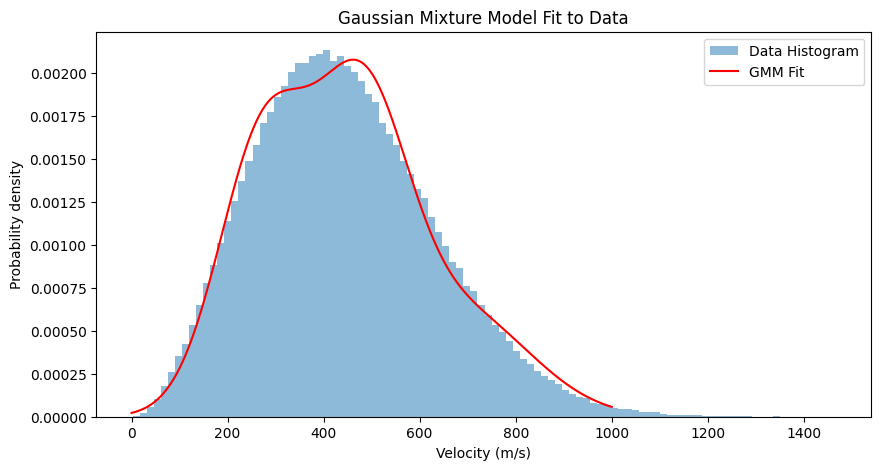

In [1]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

DATA = "../oxygen_data_aldo/Run/O2O2_collisions.csv"
rawdata = np.loadtxt(DATA, delimiter=',')
datasize = 100000
bins = 100

data = np.sqrt(rawdata[:,0]**2 + rawdata[:,1]**2 + rawdata[:,2]**2)

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(data[:datasize].reshape(-1, 1))

gmm_x = np.linspace(0,1000, datasize).reshape(-1, 1)
gmm_y = np.exp(gmm.score_samples(gmm_x))

for mu, cov, weight in zip(gmm.means_.ravel(), gmm.covariances_.ravel(), gmm.weights_.ravel()):
    sigma = np.sqrt(cov)

plt.figure(figsize=(10,5))
plt.hist(data, bins=bins, density=True, alpha=0.5,label='Data Histogram')
plt.plot(gmm_x, gmm_y, color='red', label='GMM Fit')
plt.title('Gaussian Mixture Model Fit to Data')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Probability density')
plt.legend()



# Mixeture Density Networks (MDN)

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

In [ ]:
num_mixtures = 20 # amount of mixtures
output_dim = 5 # output dimensions

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MixtureDensityNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, num_mixtures, hidden_dim=128):
        super().__init__()
        self.K = num_mixtures
        self.D = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pi_layer = nn.Linear(hidden_dim, self.K)
        self.mu_layer = nn.Linear(hidden_dim, self.K * self.D)
        self.sigma_layer = nn.Linear(hidden_dim, self.K * self.D)

    def forward(self, x):
        h = self.net(x)

        # Mixture weights
        pi = F.softmax(self.pi_layer(h), dim=-1)

        # Means
        mu = self.mu_layer(h)
        mu = mu.view(-1, self.K, self.D)

        # Standard deviations
        sigma = self.sigma_layer(h)
        # sigma = F.softplus(sigma) + 1e-6  # Ensure positivity
        sigma = torch.exp(sigma)
        sigma = sigma.view(-1, self.K, self.D)

        return pi, mu, sigma

In [ ]:
def mdn_loss(pi, mu, sigma, y):
    """
    Computes the negative log-likelihood loss for a Mixture Density Network.
    Args:
        pi: Mixture weights, shape (batch_size, K)
        mu: Means of the mixtures, shape (batch_size, K, D)
        sigma: Standard deviations of the mixtures, shape (batch_size, K, D)
        y: Target values, shape (batch_size, D)
    """
    y = y.unsqueeze(1)  # Shape (batch_size, 1, D)

    # Gaussian probability density function
    log_prob = -0.5 * (
        torch.sum(((y - mu) / sigma) ** 2 
        + 2 * torch.log(sigma) 
        + np.log(2 * np.pi), dim=-1)
    )  # Shape (batch_size, K)